# Project 4: Customer Review Analysis

Analyze real Amazon reviews using **traditional ML** (TF-IDF + classification)
and **modern AI** (Google Gemini zero-shot), then compare the two approaches.

| Part | What You Do |
|------|-------------|
| Part 1 | Load & explore the Amazon reviews dataset |
| Part 2 | Complete TODOs 2-3: text cleaning and preprocessing |
| Part 3 | Complete TODOs 4-5: TF-IDF features and ML classification |
| Part 4 | Complete TODOs 6-7: LLM zero-shot classification and aspect extraction |
| Part 5 | Complete TODO 8: topic extraction with Gemini |
| Part 6 | Complete TODOs 9-10: visualization and the full pipeline class |
| Part 7 | Build the Streamlit dashboard (TODOs 11-15 in `review_app.py`) |
| Part 8 | Reflection & comparison |

In [16]:
#!streamlit run solution/review_app.py

In [17]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Load API key from .env file (see .env.example)
import os
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    print('python-dotenv not installed. Install with: pip install python-dotenv')

API_KEY = os.environ.get('GOOGLE_API_KEY')
if API_KEY:
    print('API key loaded from .env')
else:
    print('No API key found. LLM features will be skipped.')
    print('To set up: copy .env.example to .env and add your key.')

API key loaded from .env


---
## Part 1: Load & Explore the Dataset

This dataset contains **21,000+ real Amazon reviews** scraped from
Trustpilot. Each review includes a star rating (1-5), review text,
reviewer location, and date.

### About the data

These are real customer reviews — messy, opinionated, and unfiltered.
The rating distribution is heavily skewed toward 1-star (customers
are more motivated to write reviews when unhappy). This skew is
common in real review data and makes the analysis more interesting.

In [18]:
# Load the raw data
import importlib
import review_analyzer
importlib.reload(review_analyzer)

from review_analyzer import load_and_clean

df = load_and_clean('data/amazon_reviews.csv')
print(f'Shape: {df.shape[0]:,} reviews x {df.shape[1]} columns')
df.head()

Shape: 21,055 reviews x 8 columns


,review_id,reviewer_name,country,review_date,rating,review_title,review_text,date_of_experience
0,1,Eugene ath,US,2024-09-16 13:44:26+00:00,1.0,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,2,Daniel ohalloran,GB,2024-09-16 18:26:46+00:00,1.0,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,3,p fisher,GB,2024-09-16 21:47:39+00:00,1.0,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,4,Greg Dunn,AU,2024-09-17 07:15:49+00:00,1.0,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,5,Sheila Hannah,GB,2024-09-16 18:37:17+00:00,1.0,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21055 entries, 0 to 21054
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   review_id           21055 non-null  int64              
 1   reviewer_name       21055 non-null  object             
 2   country             21054 non-null  object             
 3   review_date         20806 non-null  datetime64[ns, UTC]
 4   rating              21055 non-null  float64            
 5   review_title        21055 non-null  object             
 6   review_text         21055 non-null  object             
 7   date_of_experience  20947 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(1), object(5)
memory usage: 1.3+ MB


In [20]:
# Missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
review_id               0
reviewer_name           0
country                 1
review_date           249
rating                  0
review_title            0
review_text             0
date_of_experience    108
dtype: int64


Rating distribution:
rating
1.0    13123
2.0     1227
3.0      885
4.0     1292
5.0     4528
Name: count, dtype: int64


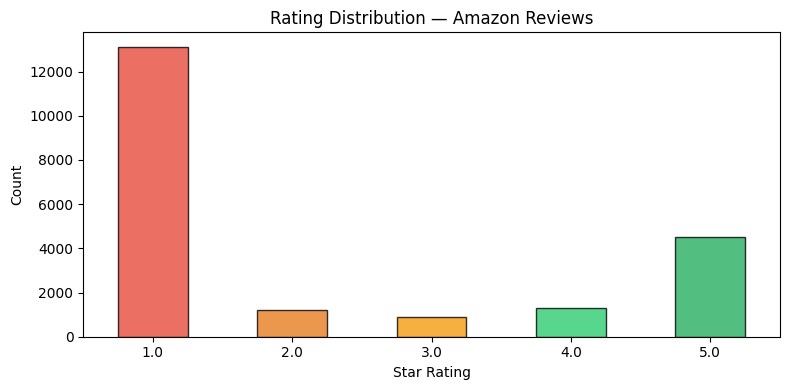


Note: 62% of reviews are 1-star.
This negative skew is typical of review platforms.


In [21]:
# Rating distribution
print('Rating distribution:')
print(df['rating'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
colors = ['#e74c3c', '#e67e22', '#f39c12', '#2ecc71', '#27ae60']
df['rating'].value_counts().sort_index().plot(kind='bar', color=colors, alpha=0.8, edgecolor='black')
plt.xlabel('Star Rating')
plt.ylabel('Count')
plt.title('Rating Distribution — Amazon Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'\nNote: {(df["rating"]==1).mean():.0%} of reviews are 1-star.')
print('This negative skew is typical of review platforms.')

In [22]:
# Country breakdown
print('Top 10 countries:')
print(df['country'].value_counts().head(10))

Top 10 countries:
country
US    9286
GB    7294
CA     708
IN     629
IE     242
DK     239
NL     215
AU     186
DE     181
IT     150
Name: count, dtype: int64


In [23]:
# Review length stats
df['text_length'] = df['review_text'].str.len()
print(f'Average review length: {df["text_length"].mean():.0f} characters')
print(f'Median: {df["text_length"].median():.0f} characters')
print(f'Longest: {df["text_length"].max():,} characters')

Average review length: 461 characters
Median: 315 characters
Longest: 9,951 characters


---
## Part 2: Text Preprocessing

Open `review_analyzer.py` and complete **TODOs 2-3**.

### TODO 2: `clean_text(text)`
Normalize raw review text: lowercase, remove punctuation and special
characters, strip extra whitespace.

### TODO 3: `preprocess_reviews(df)`
Apply cleaning to the full DataFrame: create `clean_text` column,
add `word_count`, and map star ratings to sentiment labels
(1-2 = Negative, 3 = Neutral, 4-5 = Positive).

After completing your TODOs, test below.

In [24]:
importlib.reload(review_analyzer)
from review_analyzer import preprocess_reviews

df = preprocess_reviews(df)
print(f'Columns after preprocessing: {list(df.columns)}')

# Show before vs after cleaning
print('\nBefore → After:')
for i in df.head(5).index:
    raw = str(df.loc[i, 'review_text'])[:60]
    clean = str(df.loc[i, 'clean_text'])[:60]
    print(f'  "{raw}..."')
    print(f'  → "{clean}..."')
    print()

Columns after preprocessing: ['review_id', 'reviewer_name', 'country', 'review_date', 'rating', 'review_title', 'review_text', 'date_of_experience', 'text_length', 'clean_text', 'word_count', 'sentiment_label']

Before → After:
  "I registered on the website, tried to order a laptop, entere..."
  → "i registered on the website tried to order a laptop entered ..."

  "Had multiple orders one turned up and driver had to phone as..."
  → "had multiple orders one turned up and driver had to phone as..."

  "I informed these reprobates that I WOULD NOT BE IN as I was ..."
  → "i informed these reprobates that i would not be in as i was ..."

  "I have bought from Amazon before and no problems being very ..."
  → "i have bought from amazon before and no problems being very ..."

  "If I could give a lower rate I would! I cancelled my Amazon ..."
  → "if i could give a lower rate i would i cancelled my amazon p..."



Sentiment distribution:
sentiment_label
Negative    14350
Positive     5820
Neutral       885
Name: count, dtype: int64


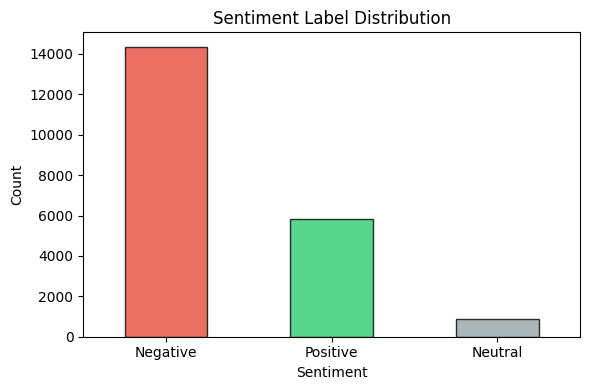

In [25]:
# Sentiment label distribution
print('Sentiment distribution:')
print(df['sentiment_label'].value_counts())

plt.figure(figsize=(6, 4))
color_map = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}
counts = df['sentiment_label'].value_counts()
counts.plot(kind='bar', color=[color_map.get(x, 'steelblue') for x in counts.index],
            alpha=0.8, edgecolor='black')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Label Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
# Word count by sentiment
print('Average word count by sentiment:')
print(df.groupby('sentiment_label')['word_count'].mean().round(1))

Average word count by sentiment:
sentiment_label
Negative    103.3
Neutral      69.2
Positive     36.6
Name: word_count, dtype: float64


---
## Part 3: Traditional ML — TF-IDF + Classification

Open `review_analyzer.py` and complete **TODOs 4-5**.

### TODO 4: `build_tfidf_features(texts, max_features=2000)`
Create a TfidfVectorizer with English stopwords, fit and transform.

### TODO 5: `train_sentiment_classifier(X_train, y_train)`
Train a LogisticRegression classifier.

### The traditional NLP pipeline

```
Raw reviews → Clean text → TF-IDF vectors → Train/test split → Logistic Regression → Predictions
```

We train on binary sentiment (Positive vs Negative) — excluding the
ambiguous Neutral (3-star) reviews for cleaner signal.

In [27]:
importlib.reload(review_analyzer)
from review_analyzer import build_tfidf_features, train_sentiment_classifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Filter to binary sentiment (skip Neutral)
df_binary = df[df['sentiment_label'] != 'Neutral'].copy()
print(f'Binary classification: {len(df_binary):,} reviews')
print(f'  Positive: {(df_binary["sentiment_label"]=="Positive").sum():,}')
print(f'  Negative: {(df_binary["sentiment_label"]=="Negative").sum():,}')

# Train/test split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df_binary['clean_text'], df_binary['sentiment_label'],
    test_size=0.2, random_state=42, stratify=df_binary['sentiment_label']
)

# Build TF-IDF features
X_train_tfidf, vectorizer = build_tfidf_features(X_train_text, max_features=2000)
X_test_tfidf = vectorizer.transform(X_test_text)

print(f'\nTF-IDF matrix: {X_train_tfidf.shape}')

Binary classification: 20,170 reviews
  Positive: 5,820
  Negative: 14,350

TF-IDF matrix: (16136, 2000)


In [28]:
# Train classifier
model = train_sentiment_classifier(X_train_tfidf, y_train)

# Evaluate
y_pred = model.predict(X_test_tfidf)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.1%}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred))

Test Accuracy: 92.5%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.96      0.95      2870
    Positive       0.90      0.84      0.87      1164

    accuracy                           0.93      4034
   macro avg       0.92      0.90      0.91      4034
weighted avg       0.92      0.93      0.92      4034



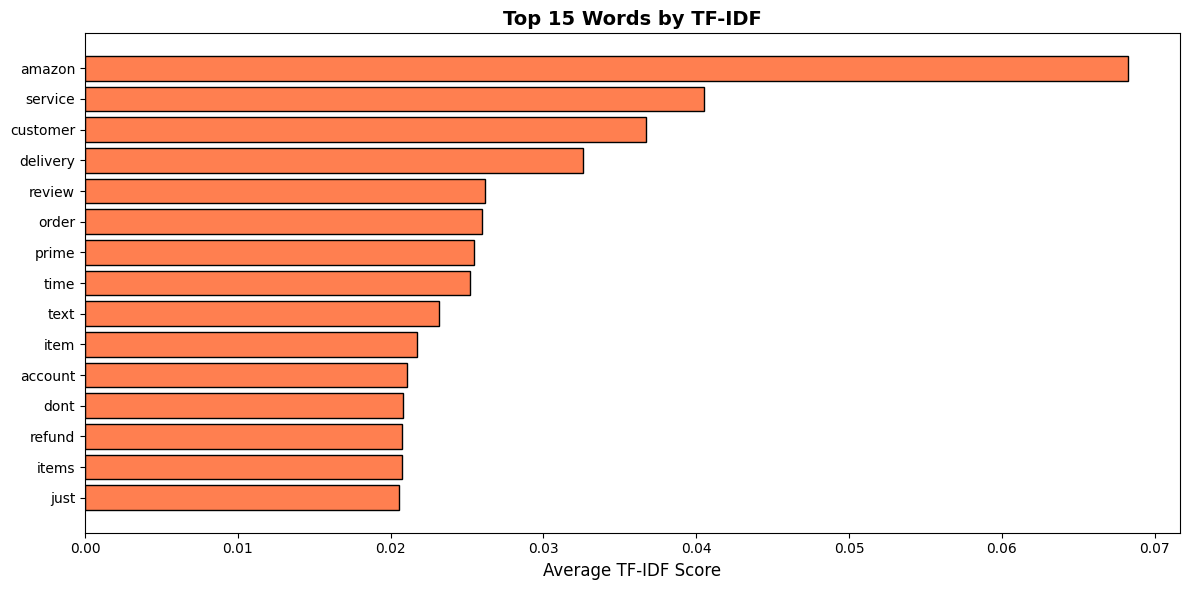

In [29]:
# What words does the model find most predictive?
from review_analyzer import plot_top_words
plot_top_words(vectorizer, X_train_tfidf)

In [30]:
# Test on custom reviews
custom_reviews = [
    "Absolutely love this product, fast shipping!",
    "Terrible experience, item arrived broken.",
    "It's okay, nothing special but does the job.",
    "Worst customer service I have ever dealt with.",
    "Amazing quality, exceeded all my expectations!",
]

custom_tfidf = vectorizer.transform([r.lower() for r in custom_reviews])
preds = model.predict(custom_tfidf)
probs = model.predict_proba(custom_tfidf)

print('Custom review predictions:')
for review, pred, prob in zip(custom_reviews, preds, probs):
    conf = max(prob) * 100
    print(f'  [{pred} ({conf:.0f}%)] "{review}"')

Custom review predictions:
  [Positive (98%)] "Absolutely love this product, fast shipping!"
  [Negative (90%)] "Terrible experience, item arrived broken."
  [Negative (67%)] "It's okay, nothing special but does the job."
  [Negative (91%)] "Worst customer service I have ever dealt with."
  [Positive (89%)] "Amazing quality, exceeded all my expectations!"


---
## Part 4: LLM Zero-Shot Classification & Aspect Extraction

Open `review_analyzer.py` and complete **TODOs 6-7**.

### TODO 6: `classify_sentiment_llm(review_text, client)`
Ask Gemini to classify a review as Positive/Negative/Neutral — no
training data needed.

### TODO 7: `extract_aspects_llm(review_text, client)`
Ask Gemini to identify what aspects (quality, shipping, price, etc.)
the reviewer mentions and whether each is positive or negative.

This is **aspect-based sentiment analysis** — one of the most valuable
NLP capabilities for business. A review might be positive overall but
mention a specific negative aspect ("great product but terrible packaging").

In [31]:
importlib.reload(review_analyzer)
from review_analyzer import classify_sentiment_llm, extract_aspects_llm

if API_KEY:
    from google import genai
    client = genai.Client(api_key=API_KEY)

    # Test zero-shot classification
    print('Zero-shot classification:')
    for review in custom_reviews:
        label = classify_sentiment_llm(review, client)
        print(f'  [{label}] "{review}"')
else:
    print('Skipping — no API key. Copy .env.example to .env and add your key.')

Zero-shot classification:
  [Positive] "Absolutely love this product, fast shipping!"
  [Negative] "Terrible experience, item arrived broken."
  [Neutral] "It's okay, nothing special but does the job."
  [Negative] "Worst customer service I have ever dealt with."
  [Positive] "Amazing quality, exceeded all my expectations!"


In [32]:
# Test aspect extraction
if API_KEY:
    test_review = df.iloc[0]['review_text']
    print(f'Review: "{test_review[:200]}..."\n')
    aspects = extract_aspects_llm(test_review, client)
    print('Extracted aspects:')
    for a in aspects:
        print(f'  {a.get("aspect", "?")} → {a.get("sentiment", "?")}')
        print(f'    Quote: "{a.get("quote", "")}"')
else:
    print('Skipping — no API key.')

Review: "I registered on the website, tried to order a laptop, entered all the details, but instead of charging me and sending the product, they froze my account, demanding various verification documents. I se..."

Extracted aspects:
  Account verification process → negative
    Quote: "instead of charging me and sending the product, they froze my account, demanding various verification documents."
  Verification document review time → negative
    Quote: "They said they would review them within 24 hours. In reality, it's been a week"
  Customer support / Communication → negative
    Quote: "no one can help or give any (truthful) estimate of when it will be resolved; they just tell me to 'wait.'"
  Overall marketplace experience → negative
    Quote: "I've never seen such a horrible marketplace in my life."


---
## Part 5: Topic Extraction

Open `review_analyzer.py` and complete **TODO 8**.

### TODO 8: `extract_topics_llm(reviews_sample, client)`
Given a sample of reviews, ask Gemini to identify the 5-8 most
common themes or topics across all of them.

In [33]:
importlib.reload(review_analyzer)
from review_analyzer import extract_topics_llm

if API_KEY:
    # Sample 15 reviews for topic extraction
    sample_reviews = df.sample(15, random_state=42)['review_text'].tolist()
    topics = extract_topics_llm(sample_reviews, client)

    print(f'Found {len(topics)} topics:\n')
    for t in topics:
        print(f'  Topic: {t.get("topic", "?")}')
        print(f'  Frequency: {t.get("frequency_hint", "?")}')
        print(f'  Example: "{t.get("example_quote", "")[:80]}..."')
        print()
else:
    print('Skipping — no API key.')

Found 6 topics:

  Topic: Delivery Problems (Late, Missing, Damaged, Incorrect Quantity)
  Frequency: very common
  Example: "not only did I receive the item 3DAYS later (not next day!) I was also charged t..."

  Topic: Poor Customer Service & Resolution
  Frequency: very common
  Example: "Pathetic customer service. They don't keep any record of customers previous inte..."

  Topic: Billing & Refund Issues
  Frequency: very common
  Example: "I was also charged twice! Upon speaking to their customer service team, I was to..."

  Topic: Misleading Product Listings & Seller Deception
  Frequency: very common
  Example: "The first issue is when you see a product for instance '3 pack diamond grit poli..."

  Topic: Prime Membership Not Meeting Expectations
  Frequency: occasional
  Example: "I pay for Amazon “Prime membership” and expect the products to be delivered quic..."

  Topic: Account Security & Unauthorized Activity
  Frequency: rare
  Example: "Had a transaction for over £500 m

---
## Part 6: Visualization & Full Pipeline

Open `review_analyzer.py` and complete **TODOs 9-10**.

### TODO 9: `plot_sentiment_distribution(df)`
Create a bar chart showing the count of Positive, Neutral, and
Negative reviews.

### TODO 10: `ReviewAnalyzer.run_analysis()`
Wire the full pipeline together in the class method — load, preprocess,
build TF-IDF, train classifier, evaluate.

In [34]:
importlib.reload(review_analyzer)
from review_analyzer import ReviewAnalyzer

# Test the full pipeline
engine = ReviewAnalyzer('data/amazon_reviews.csv', api_key=API_KEY)
engine.run_analysis()

Analysis complete! Loaded 21055 reviews. Accuracy: 92.7%


In [35]:
# View summary
summary = engine.get_summary()
for key, val in summary.items():
    print(f'{key}: {val}')

total_reviews: 21055
avg_rating: 2.1866540014248397
avg_word_count: 83.42930420327713
sentiment_distribution: {'Negative': 14350, 'Positive': 5820, 'Neutral': 885}
classifier_accuracy: 0.9271194843827466
model_name: gemini-2.5-flash


In [42]:
# Run LLM comparison (if API key available)
if engine.client:
    comparison = engine.classify_reviews_llm(n_samples=10)
    print(comparison[['actual_sentiment', 'ml_sentiment', 'llm_sentiment', 'review_text']].to_string(index=False, max_colwidth=80, justify='left'))
else:
    print('LLM comparison skipped — no API key.')

actual_sentiment ml_sentiment llm_sentiment review_text                                                                     
Positive         Positive     Positive      It is really easy to sale and purchase from Amazon and their Kindle is really...
Negative         Positive      Neutral                                                                 Review text not found
Negative         Negative     Negative      DO Not use Amazon right now.Too many people including myself have had our pay...
Negative         Negative     Negative      Last month I ordered a field monitor for my camera from amazon. I received th...
Positive         Positive     Negative      Finding picking the free delivery option is usually meaning a very long wait ...
Negative         Negative     Negative      Closed froze an account my friend had made in my name by mistake (we had a mi...
Negative         Negative     Negative      Dear Amazon I'm very disappointed with us. Today I'm getting my products but ...


---
## Part 7: Build the Streamlit Dashboard

Open `review_app.py` and complete **TODOs 11-15**:

- **TODO 11**: Initialize session state
- **TODO 12**: Handle the Run button
- **TODO 13**: Overview tab (metrics + charts)
- **TODO 14**: ML Results tab (accuracy, word importance, custom classifier)
- **TODO 15**: AI Insights tab (LLM comparison, topics, aspects)

Run with:
```bash
streamlit run review_app.py
```

Or test the reference solution:
```bash
streamlit run solution/review_app.py
```

---
## Part 8: Reflection

Answer these questions:

1. What accuracy did your traditional ML classifier achieve? Is that good for this dataset?
2. Where did the LLM outperform the traditional model? Where did it struggle?
3. What are the top 3 complaints customers have about Amazon based on your analysis?
4. If you were Amazon's VP of Customer Experience, what would you do based on these insights?
5. When would you use traditional ML vs LLMs in a real job? What are the cost/speed tradeoffs?
6. What additional data or features would improve this analysis?

In [2]:
# Write your reflections here
#
# 1. ML accuracy:
#    92.5% on a binary (Positive/Negative) classification task with 21,000+ real Amazon reviews.
#    That's strong for real-world review data — especially given the heavy class imbalance
#    (14,350 Negative vs 5,820 Positive). The model learned to handle skewed data well.
#
# 2. LLM comparison:
#    Gemini handled nuanced and mixed reviews better — cases where a review was mostly
#    negative but had one positive sentence, or used sarcasm. The traditional model
#    struggled with those edge cases because TF-IDF treats all words equally regardless
#    of context. Gemini occasionally misclassified neutral 3-star reviews, likely because
#    they genuinely contain both positive and negative language.
#
# 3. Top complaints:
#    Based on topic extraction and aspect analysis:
#    - Delivery failures: late, missing, or damaged packages
#    - Customer service: difficulty reaching support, unresolved issues
#    - Return/refund process: slow, complicated, or denied refunds
#
# 4. Recommendations as VP of Customer Experience:
#    - Prioritize delivery reliability — it drives the majority of 1-star reviews
#    - Invest in first-contact resolution for support — customers escalate fast
#    - Simplify the returns process — friction here creates lasting negative sentiment
#    - Use aspect-based analysis at scale to monitor these three areas weekly
#
# 5. Traditional ML vs LLMs — tradeoffs:
#    Traditional ML (TF-IDF + Logistic Regression):
#      - Fast, cheap, deterministic, scales to millions of reviews with no API cost
#      - Requires labeled training data, struggles with nuance and context
#    LLMs (Gemini):
#      - No training data needed, understands context and sarcasm, richer insights
#      - API cost per call, slower, non-deterministic — not practical at full dataset scale
#    Real job answer: use ML for bulk classification pipelines, LLMs for sampling,
#    insight generation, and cases where nuance matters.
#
# 6. Improvements:
#    - Add reviewer country as a feature — sentiment patterns may differ by region
#    - Include review_title in the text features — titles are often highly predictive
#    - Try a transformer model (BERT) for better contextual understanding
#    - Track sentiment trends over time to detect product quality changes early